# PART 1. AI-Based Parental Alert System for Detecting Harmful Online Content

## Introduction

With the rapid growth of social media and digital communication platforms, children and teenagers are increasingly exposed to online interactions. While these platforms enable communication and information sharing, they also pose risks such as cyberbullying, harassment, and exposure to harmful language. These issues can negatively impact mental health and emotional well-being, making it important to identify harmful content at an early stage.

Manual monitoring of online conversations is difficult due to the large volume of messages and continuous user activity. This creates a need for automated systems that can assist in identifying harmful content efficiently.

In this project, an AI-based system is developed to detect harmful or abusive text using Natural Language Processing (NLP) and Machine Learning techniques. The system classifies input text into two categories: Safe and Harmful, allowing quick identification of potentially harmful interactions.

To achieve this, different text representation techniques are explored, including TF-IDF and transformer-based embeddings using a pretrained MiniLM model. Multiple machine learning models such as Logistic Regression, Support Vector Machine (SVM), and Random Forest are implemented and compared. In addition, an LSTM-based deep learning model is also developed to capture sequential patterns in text.

Based on performance evaluation using metrics such as accuracy, precision, recall, F1-score, and confusion matrix, the BERT-like transformer embeddings combined with SVM are selected as the final model due to their balanced performance and efficiency.

The final system is deployed as a Streamlit web application, where users can input text and receive real-time predictions. The application also includes an alert mechanism for harmful content and maintains a history of detected cases with timestamps.

This project focuses on building an end-to-end practical system for detecting harmful online content and demonstrates how AI can assist in creating safer digital environments.

## Objectives

The main objectives of this project are:

- To detect harmful online content using NLP techniques  
- To classify text into Safe and Harmful categories  
- To compare different feature extraction and modelling approaches  
- To build a real-time application for content detection  
- To assist in identifying harmful interactions early  

## Methodology Overview

The project follows a structured pipeline:

1. Data Collection and Preprocessing  
2. Dataset Balancing  
3. Feature Extraction (TF-IDF and Transformer Embeddings)  
4. Model Training (ML and Deep Learning)  
5. Model Evaluation  
6. Deployment using Streamlit  

This approach ensures systematic development and evaluation of the system.

## Step 1. Dataset Description and Preprocessing

The dataset used in this project consists of social media text collected from multiple sources, including platforms such as Twitter and other online communication channels. The data contains user-generated messages labeled to indicate whether the content is harmful (e.g., abusive, toxic, or offensive) or safe.

To simplify the problem, the original labels were converted into a binary classification format:
- 0 → Safe  
- 1 → Harmful  

Since the dataset was imbalanced, downsampling was applied to ensure a balanced distribution of both classes. A subset of approximately 20,000 samples was then used for efficient training and evaluation.

### Data Cleaning

Before training the models, the text data was preprocessed to improve quality and consistency. The following steps were performed:

- Converted all text to lowercase  
- Removed special characters, numbers, and punctuation  
- Removed URLs and unnecessary symbols  
- Eliminated noise and irregular formatting  

These preprocessing steps help the models focus on meaningful textual patterns and improve overall performance.

### STEP 1.1: Load Dataset

In [3]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("saurabhshahane/cyberbullying-dataset")

# Check files
print(os.listdir(path))
df = pd.read_csv(path + "/twitter_parsed_dataset.csv")
df.head()


['aggression_parsed_dataset.csv', 'attack_parsed_dataset.csv', 'kaggle_parsed_dataset.csv', 'toxicity_parsed_dataset.csv', 'twitter_parsed_dataset.csv', 'twitter_racism_parsed_dataset.csv', 'twitter_sexism_parsed_dataset.csv', 'youtube_parsed_dataset.csv']


,index,id,Text,Annotation,oh_label
0,5.74948705591165E+017,5.74948705591165E+017,@halalflaws @biebervalue @greenlinerzjm I read...,none,0.0
1,5.71917888690393E+017,5.71917888690393E+017,@ShreyaBafna3 Now you idiots claim that people...,none,0.0
2,3.90255841338601E+017,3.90255841338601E+017,"RT @Mooseoftorment Call me sexist, but when I ...",sexism,1.0
3,5.68208850655916E+017,5.68208850655916E+017,"@g0ssipsquirrelx Wrong, ISIS follows the examp...",racism,1.0
4,5.75596338802373E+017,5.75596338802373E+017,#mkr No No No No No No,none,0.0


In [4]:
import pandas as pd

df1 = pd.read_csv(path + "/twitter_parsed_dataset.csv")
df2 = pd.read_csv(path + "/toxicity_parsed_dataset.csv")
df3 = pd.read_csv(path + "/aggression_parsed_dataset.csv")
df4 = pd.read_csv(path + "/attack_parsed_dataset.csv")
df5 = pd.read_csv(path + "/youtube_parsed_dataset.csv")

In [5]:
df1 = df1.rename(columns={"Text": "text", "oh_label": "label"})
df2 = df2.rename(columns={"Text": "text", "oh_label": "label"})
df3 = df3.rename(columns={"Text": "text", "oh_label": "label"})
df4 = df4.rename(columns={"Text": "text", "oh_label": "label"})
df5 = df5.rename(columns={"Text": "text", "oh_label": "label"})

In [6]:
df1 = df1[["text", "label"]]
df2 = df2[["text", "label"]]
df3 = df3[["text", "label"]]
df4 = df4[["text", "label"]]
df5 = df5[["text", "label"]]

In [7]:
df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

In [8]:
df = df.dropna()
df = df.drop_duplicates()

print("Final dataset size:", len(df))
df.head()

Final dataset size: 223051


,text,label
0,@halalflaws @biebervalue @greenlinerzjm I read...,0.0
1,@ShreyaBafna3 Now you idiots claim that people...,0.0
2,"RT @Mooseoftorment Call me sexist, but when I ...",1.0
3,"@g0ssipsquirrelx Wrong, ISIS follows the examp...",1.0
4,#mkr No No No No No No,0.0


## Class Distribution Before Balancing

In this step, we visualize the distribution of classes in the dataset to understand the imbalance between safe and harmful messages.

In [9]:
df["label"].value_counts()

label
0.0    198123
1.0     24928
Name: count, dtype: int64

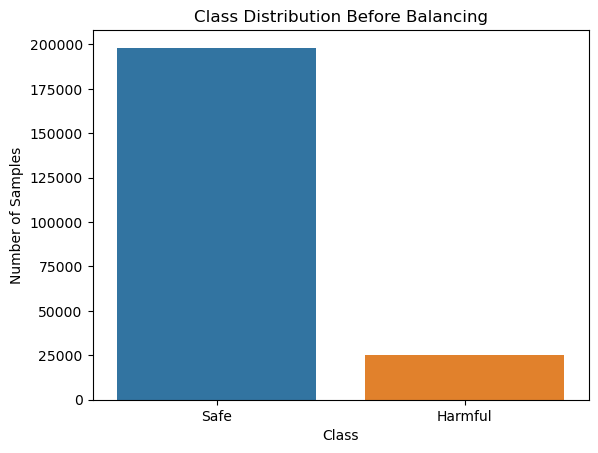

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="label", data=df)
plt.title("Class Distribution Before Balancing")
plt.xticks([0,1], ["Safe", "Harmful"])
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

## Step 2.  Dataset Balancing

The dataset is highly imbalanced, with a majority of safe messages compared to harmful ones. To address this issue, undersampling is applied to create a balanced dataset, ensuring the model learns equally from both classes.

### Apply Undersampling

In [12]:
# Separate classes
df_safe = df[df["label"] == 0]
df_harm = df[df["label"] == 1]

# Undersample safe class
df_safe_sampled = df_safe.sample(len(df_harm), random_state=42)

# Combine
df_balanced = pd.concat([df_safe_sampled, df_harm])

In [13]:
df_balanced = df_balanced.sample(frac=1, random_state=42)

In [14]:
df_balanced["label"].value_counts()

label
0.0    24928
1.0    24928
Name: count, dtype: int64

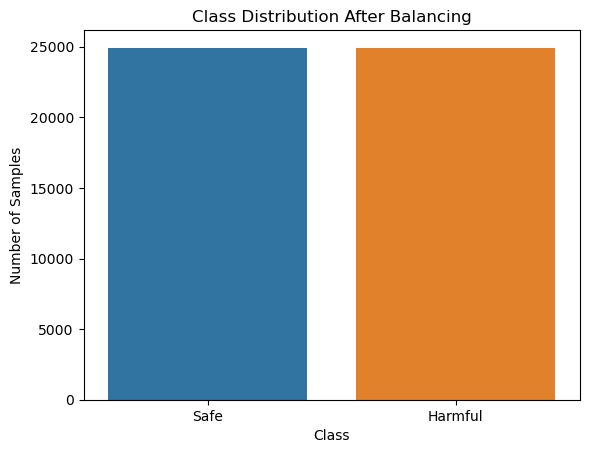

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="label", data=df_balanced)
plt.title("Class Distribution After Balancing")
plt.xticks([0,1], ["Safe", "Harmful"])
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

## Class Distribution After Balancing

After applying undersampling, the dataset has been balanced to ensure equal representation of both classes. The number of safe and harmful messages is now the same, which helps prevent bias in the model during training.

Balancing the dataset is important because an imbalanced dataset can cause the model to favor the majority class, leading to poor performance in detecting harmful content. By creating a balanced dataset, the model can learn patterns from both classes more effectively and provide more reliable predictions.

### 2.1.  Dataset Exploration

In this step, we explore the dataset to understand its structure, sample data, and overall characteristics before applying preprocessing and modeling techniques.

In [14]:
df_balanced.sample(5)

,text,label
102818,` ::::Italy???? Rome???? What the fuck has th...,1.0
137324,"` :::::No, my agry replies are only part of th...",0.0
175052,"` :::oh shit, nooooo, is someone going to span...",1.0
74122,` == Alawis == hello im new to this and dont q...,0.0
154505,"These, on that page you're supposed to be fo...",0.0


In [15]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_balanced["clean_text"] = df_balanced["text"].apply(clean_text)

In [16]:
df_balanced["text_length"] = df_balanced["clean_text"].apply(len)
df_balanced["text_length"].describe()

count    49856.000000
mean       345.401256
std        723.043010
min          0.000000
25%         69.000000
50%        134.000000
75%        326.000000
max      10531.000000
Name: text_length, dtype: float64

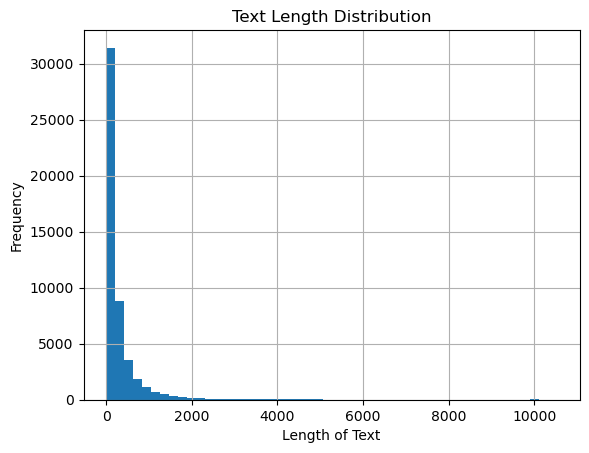

In [17]:
import matplotlib.pyplot as plt

df_balanced["text_length"].hist(bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length of Text")
plt.ylabel("Frequency")
plt.show()

The text length distribution shows that most messages are relatively short, which is typical for social media data. A small number of longer texts are present, resulting in a right-skewed distribution. This variation helps the model learn from both short and detailed textual inputs.

In [18]:
from collections import Counter

all_words = " ".join(df_balanced["clean_text"]).split()
common_words = Counter(all_words).most_common(20)

print(common_words)

[('the', 120010), ('you', 91765), ('to', 77016), ('a', 70505), ('i', 68908), ('and', 63261), ('of', 56913), ('is', 53137), ('that', 39343), ('in', 36987), ('it', 33608), ('this', 26482), ('for', 25791), ('are', 24834), ('not', 24667), ('your', 24353), ('on', 22928), ('be', 20594), ('have', 19530), ('as', 17941)]


In [19]:
!pip install wordcloud

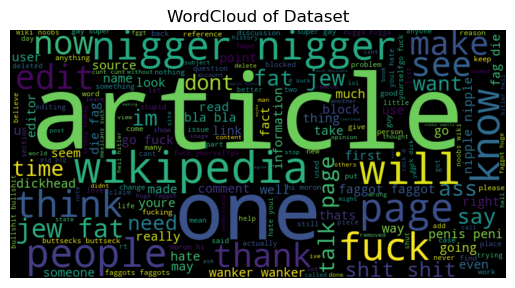

In [20]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400).generate(" ".join(df_balanced["clean_text"]))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Dataset")
plt.show()

### WordCloud Analysis

The WordCloud visualization highlights the most frequently occurring words in the dataset. It is evident that many commonly appearing terms are associated with offensive, abusive, and toxic language, which is expected in a cyberbullying detection dataset.

This indicates that the dataset contains meaningful patterns related to harmful communication. Such patterns are important for training machine learning models to effectively distinguish between safe and harmful content.

Overall, the WordCloud provides a quick visual understanding of the dominant terms in the dataset and confirms the presence of relevant features for classification.

In [21]:
print("Safe samples:")
print(df_balanced[df_balanced["label"] == 0]["text"].sample(3))

print("\nHarmful samples:")
print(df_balanced[df_balanced["label"] == 1]["text"].sample(3))

Safe samples:
164591              ::Thanks for taking a look, cheers.    
132409    `::::Deskana, what is your point of saying ``b...
153653    In the first stage of the British plan, both d...
Name: text, dtype: object

Harmful samples:
62935    `  ==City departments==  As of 70 minutes ago,...
94471        ==Miss Tourism World is run by the THE BIG...
12589    RT @jjordon96: Pretty sure that #gamergate epi...
Name: text, dtype: object


# Observations from Data Exploration

The dataset contains a wide variety of textual data from different social media platforms. The WordCloud visualization highlights frequently occurring words, many of which are associated with toxic or abusive language.

Sample inspection of the data shows a clear distinction between safe and harmful messages. Harmful messages often include offensive, aggressive, or abusive terms, while safe messages consist of neutral or conversational text.

These observations confirm that the dataset is suitable for training a model to detect harmful content effectively.

# Step 3.1. Feature Extraction using Transformer Embeddings (MiniLM)

In this step, the textual data is converted into numerical representations using a pretrained transformer-based model from the sentence-transformers library. Specifically, the all-MiniLM-L6-v2 model is used to generate sentence-level embeddings.

Unlike traditional methods such as TF-IDF, which rely on word frequency, transformer-based embeddings capture the semantic meaning of the entire sentence by considering the context of words.

Each input text is passed through the MiniLM model to obtain a fixed-length vector representation. These embeddings are then used as input features for machine learning models such as Logistic Regression, Support Vector Machine (SVM), and Random Forest.

This approach allows the models to learn from meaningful representations of text, leading to improved performance compared to traditional feature extraction methods, while also being efficient and suitable for real-time applications.

## Why BERT is not directly used and its relation to MiniLM

In this project, a full BERT model was not directly used due to its high computational cost and slower inference time. BERT is a large transformer model that requires significant memory and processing power, which can make it less suitable for real-time applications.

Instead, a lightweight transformer model called MiniLM (all-MiniLM-L6-v2) is used. MiniLM is a distilled version of larger transformer models like BERT, meaning it is trained to retain similar contextual understanding while being smaller and faster.

Although MiniLM is not the original BERT model, it is based on the same transformer architecture and uses similar attention mechanisms to capture the relationships between words in a sentence. This allows it to generate meaningful sentence embeddings efficiently.

Therefore, MiniLM provides a good balance between performance and efficiency, making it suitable for this project where real-time prediction and deployment are important.

In [35]:
!pip install sentence-transformers

In [37]:
!pip install --upgrade sentence-transformers
!pip install --upgrade huggingface_hub
!pip install --upgrade datasets

  Obtaining dependency information for datasets from https://files.pythonhosted.org/packages/b0/e5/247d094108e42ac26363ab8dc57f168840cf7c05774b40ffeb0d78868fcc/datasets-4.8.4-py3-none-any.whl.metadata
  Obtaining dependency information for pyarrow>=21.0.0 from https://files.pythonhosted.org/packages/00/ca/db94101c187f3df742133ac837e93b1f269ebdac49427f8310ee40b6a58f/pyarrow-23.0.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for requests>=2.32.2 from https://files.pythonhosted.org/packages/d7/8e/7540e8a2036f79a125c1d2ebadf69ed7901608859186c856fa0388ef4197/requests-2.33.1-py3-none-any.whl.metadata
  Obtaining dependency information for tqdm>=4.66.3 from https://files.pythonhosted.org/packages/16/e1/3079a9ff9b8e11b846c6ac5c8b5bfb7ff225eee721825310c91b3b50304f/tqdm-4.67.3-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     --------------------- ------------------ 30.7/57.7 kB 1.3 MB/s eta 0:00:01
     -------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.75 requires requests_mock, which is not installed.
conda-repo-cli 1.0.75 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.75 requires PyYAML==6.0.1, but you have pyyaml 6.0 which is incompatible.
conda-repo-cli 1.0.75 requires requests==2.31.0, but you have requests 2.33.1 which is incompatible.
s3fs 2023.4.0 requires fsspec==2023.4.0, but you have fsspec 2026.2.0 which is incompatible.


## Transformer Model Initialization

A pre-trained transformer model (all-MiniLM-L6-v2) from the sentence-transformers library is loaded to generate semantic embeddings for the textual data. This model captures contextual meaning by considering relationships between words within a sentence.

The generated embeddings provide a meaningful numerical representation of the text, which is then used as input for machine learning models. This approach improves feature representation compared to traditional methods such as TF-IDF.

In [22]:
from sentence_transformers import SentenceTransformer

bert_model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\91702\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\91702\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [23]:
sample_df = df_balanced.sample(20000, random_state=42)

X = sample_df["clean_text"].tolist()
y = sample_df["label"]

In [24]:
X_embeddings = bert_model.encode(X, show_progress_bar=True)

Batches:   0%|          | 0/625 [00:00<?, ?it/s]

In [25]:
print(X_embeddings.shape)

(20000, 384)


In [26]:
print(y.value_counts())

label
1.0    10094
0.0     9906
Name: count, dtype: int64


In [27]:
import numpy as np

print(np.isnan(X_embeddings).sum())

0


## Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y, test_size=0.2, random_state=42
)

## A.  Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score, classification_report

In [33]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.8415
              precision    recall  f1-score   support

         0.0       0.85      0.84      0.84      2019
         1.0       0.83      0.85      0.84      1981

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000



## B. SVM

In [30]:
from sklearn.svm import SVC

model_svm = SVC()
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

In [34]:
print("SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM
Accuracy: 0.85025
              precision    recall  f1-score   support

         0.0       0.86      0.84      0.85      2019
         1.0       0.84      0.86      0.85      1981

    accuracy                           0.85      4000
   macro avg       0.85      0.85      0.85      4000
weighted avg       0.85      0.85      0.85      4000



## C.  Random Forest 

In [31]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [35]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.816
              precision    recall  f1-score   support

         0.0       0.82      0.81      0.82      2019
         1.0       0.81      0.82      0.82      1981

    accuracy                           0.82      4000
   macro avg       0.82      0.82      0.82      4000
weighted avg       0.82      0.82      0.82      4000



# Transformer Embedding Model Performance Analysis

The models trained using transformer-based embeddings (MiniLM) show strong performance in detecting harmful content. Among the models, Support Vector Machine (SVM) achieved the highest accuracy, indicating its effectiveness in handling high-dimensional embedding features.

Logistic Regression also performed well and served as a strong baseline model. Random Forest showed comparatively lower performance, which may be due to its limitations in effectively handling dense numerical embeddings.

Overall, transformer-based embeddings improved classification performance by capturing the contextual meaning of text, leading to better results compared to traditional feature extraction methods.

# Model Saving and Evaluation

### Saving the Trained Model

After training the Support Vector Machine (SVM) model using transformer-based embeddings, the trained model is saved using the `joblib` library. This allows the model to be reused later without retraining, which is useful for deployment in applications such as Streamlit.

---

### Transformer Model Loading

The pretrained MiniLM model (`all-MiniLM-L6-v2`) is loaded using the SentenceTransformer library. This model is used to generate sentence embeddings for input text.

During loading, a warning related to unexpected keys may appear. This is normal when loading models across slightly different configurations and can be safely ignored as it does not affect functionality.

---

### Model Information Storage

Basic information about the trained model, including the model type (SVM), embedding method (MiniLM), and class labels (Safe and Harmful), is stored separately. This helps in maintaining clarity and documentation for deployment and future use.

---



In [36]:
import joblib

joblib.dump(model_svm, "svm_bert_model.pkl")

['svm_bert_model.pkl']

In [37]:
SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)

In [38]:
model_info = {
    "model": "SVM",
    "embedding": "BERT (MiniLM)",
    "classes": ["Safe", "Harmful"]
}

joblib.dump(model_info, "model_info.pkl")

['model_info.pkl']

### Confusion Matrix Evaluation

To evaluate model performance, a confusion matrix is generated. This matrix provides a detailed breakdown of:

- Correct predictions for Safe and Harmful classes  
- Incorrect predictions (false positives and false negatives)  

The confusion matrix is visualized using a heatmap, making it easier to interpret the model’s performance and identify potential areas of improvement.

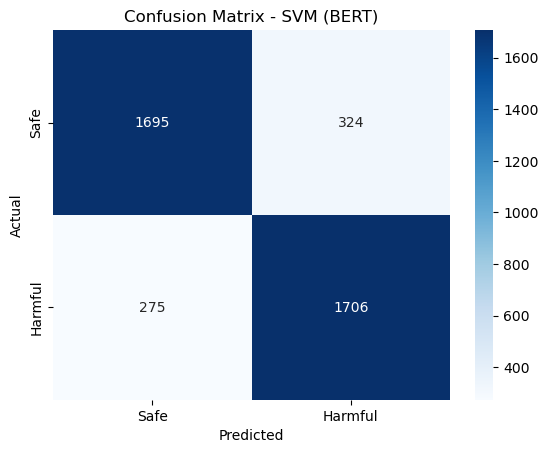

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Safe", "Harmful"],
            yticklabels=["Safe", "Harmful"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM (BERT)")
plt.show()

##  Step 3.2 .Feature Extraction using TF-IDF

In this step, the textual data is converted into numerical features using the TF-IDF (Term Frequency–Inverse Document Frequency) technique. TF-IDF represents text based on the importance of words in a document relative to the entire dataset.

Unlike transformer-based embeddings, TF-IDF does not capture contextual meaning but provides a simple and effective baseline for text representation.

A maximum of 5000 features is used to limit the vocabulary size and improve computational efficiency.

---

### Model Training using TF-IDF Features

The TF-IDF features are split into training and testing sets. Multiple machine learning models are then trained using these features:

- Logistic Regression  
- Support Vector Machine (SVM)  
- Random Forest  

These models are evaluated using accuracy and classification metrics to compare their performance.

---

### Performance Observation

The TF-IDF based models achieved good performance, with Logistic Regression and SVM showing strong results. However, since TF-IDF does not capture contextual relationships between words, its performance is slightly lower compared to transformer-based embeddings.

This step serves as a baseline to evaluate the improvement achieved using more advanced feature extraction methods.

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use same sampled data for fair comparison
X = sample_df["clean_text"]
y = sample_df["label"]

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

In [42]:
from sklearn.model_selection import train_test_split

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.metrics import accuracy_score, classification_report

## A.  Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression

model_lr_tfidf = LogisticRegression(max_iter=1000)
model_lr_tfidf.fit(X_train_tfidf, y_train)

y_pred_lr_tfidf = model_lr_tfidf.predict(X_test_tfidf)

In [47]:
print("TF-IDF Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_tfidf))
print(classification_report(y_test, y_pred_lr_tfidf))

TF-IDF Logistic Regression
Accuracy: 0.8425
              precision    recall  f1-score   support

         0.0       0.84      0.85      0.84      2019
         1.0       0.84      0.84      0.84      1981

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000



 ## B. SVM

In [44]:
from sklearn.svm import SVC

model_svm_tfidf = SVC()
model_svm_tfidf.fit(X_train_tfidf, y_train)

y_pred_svm_tfidf = model_svm_tfidf.predict(X_test_tfidf)

In [48]:
print("TF-IDF SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_tfidf))
print(classification_report(y_test, y_pred_svm_tfidf))

TF-IDF SVM
Accuracy: 0.84575
              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85      2019
         1.0       0.85      0.84      0.84      1981

    accuracy                           0.85      4000
   macro avg       0.85      0.85      0.85      4000
weighted avg       0.85      0.85      0.85      4000



## C.  Random Forest 

In [45]:
from sklearn.ensemble import RandomForestClassifier

model_rf_tfidf = RandomForestClassifier(n_estimators=100)
model_rf_tfidf.fit(X_train_tfidf, y_train)

y_pred_rf_tfidf = model_rf_tfidf.predict(X_test_tfidf)

In [49]:
print("TF-IDF Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tfidf))
print(classification_report(y_test, y_pred_rf_tfidf))

TF-IDF Random Forest
Accuracy: 0.7995
              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81      2019
         1.0       0.82      0.77      0.79      1981

    accuracy                           0.80      4000
   macro avg       0.80      0.80      0.80      4000
weighted avg       0.80      0.80      0.80      4000



 ## Comparative Analysis of Models

| Feature Type | Model | Accuracy |
|-------------|------|---------|
| BERT | SVM | **85.02%** |
| BERT | Logistic Regression | 84.15% |
| BERT | Random Forest | 81.60% |
| TF-IDF | SVM | 84.57% |
| TF-IDF | Logistic Regression | 84.25% |
| TF-IDF | Random Forest | 79.95% |

### Comparative Analysis

The comparison between TF-IDF and transformer-based models (MiniLM embeddings) shows that both approaches perform well for cyberbullying detection. However, transformer-based embeddings slightly outperform TF-IDF due to their ability to capture contextual meaning in text.

TF-IDF also achieved competitive performance, indicating that traditional feature extraction methods can still be effective when combined with strong classifiers such as SVM.

Among all the models evaluated, Support Vector Machine (SVM) consistently performed the best across both TF-IDF and transformer-based features, making it the most suitable choice for this classification task.

## Model Testing with Sample Inputs

In this step, the trained model is tested using custom input sentences to evaluate its performance on real-world examples. This helps in understanding how the model behaves with unseen data.

In [51]:
def predict_text(text):
    # Clean text
    import re
    text_clean = text.lower()
    text_clean = re.sub(r"http\S+", "", text_clean)
    text_clean = re.sub(r"@\w+", "", text_clean)
    text_clean = re.sub(r"[^a-zA-Z\s]", "", text_clean)
    
    # Convert to embedding
    embedding = bert_model.encode([text_clean])
    
    # Predict
    pred = model_svm.predict(embedding)[0]
    
    return "Harmful" if pred == 1 else "Safe"

In [52]:
texts = [
    "I hope you have a great day!",
    "You are such an idiot",
    "I will kill you",
    "This is a normal conversation",
    "You are worthless and stupid"
]

for t in texts:
    print(f"Text: {t}")
    print("Prediction:", predict_text(t))
    print("-" * 50)

Text: I hope you have a great day!
Prediction: Safe
--------------------------------------------------
Text: You are such an idiot
Prediction: Harmful
--------------------------------------------------
Text: I will kill you
Prediction: Harmful
--------------------------------------------------
Text: This is a normal conversation
Prediction: Safe
--------------------------------------------------
Text: You are worthless and stupid
Prediction: Harmful
--------------------------------------------------


In [53]:
def predict_with_alert(text):
    import re
    
    text_clean = text.lower()
    text_clean = re.sub(r"[^a-zA-Z\s]", "", text_clean)
    
    embedding = bert_model.encode([text_clean])
    pred = model_svm.predict(embedding)[0]
    
    if pred == 0:
        return "Safe"
    
    # Severity check
    if any(word in text_clean for word in ["kill", "die", "rape", "murder"]):
        return "Danger"
    
    return "Warning"

In [54]:
for t in texts:
    print(f"Text: {t}")
    print("Alert Level:", predict_with_alert(t))
    print("-" * 50)

Text: I hope you have a great day!
Alert Level: Safe
--------------------------------------------------
Text: You are such an idiot
Alert Level: Warning
--------------------------------------------------
Text: I will kill you
Alert Level: Danger
--------------------------------------------------
Text: This is a normal conversation
Alert Level: Safe
--------------------------------------------------
Text: You are worthless and stupid
Alert Level: Warning
--------------------------------------------------


### Prediction Analysis

The model was tested with various sample inputs to evaluate its real-world performance. The results show that the model successfully distinguishes between safe and harmful text.

Additionally, a rule-based alert system was implemented to further classify harmful content into warning and dangerous categories, enhancing the practical usability of the system.

## User Input Testing

In this step, the system is tested with user-provided input to evaluate real-time predictions. This allows dynamic interaction with the model and demonstrates its practical usability.

In [56]:
while True:
    user_input = input("Enter a message (or type 'exit' to quit): ")
    
    if user_input.lower() == "exit":
        print("Exiting...")
        break
    
    result = predict_with_alert(user_input)
    
    print("Alert Level:", result)
    print("-" * 50)

Enter a message (or type 'exit' to quit): Women are not good at making decisions, they should stay in the kitchen.
Alert Level: Warning
--------------------------------------------------
Enter a message (or type 'exit' to quit): People of your race are always causing problems everywhere.
Alert Level: Warning
--------------------------------------------------
Enter a message (or type 'exit' to quit): Men are always better than women at this kind of work.
Alert Level: Warning
--------------------------------------------------
Enter a message (or type 'exit' to quit): i love india
Alert Level: Safe
--------------------------------------------------
Enter a message (or type 'exit' to quit): I don't like you because of your skin color, you people are all the same.
Alert Level: Warning
--------------------------------------------------
Enter a message (or type 'exit' to quit): good morning
Alert Level: Safe
--------------------------------------------------
Enter a message (or type 'exit' to

# Step 3.3  LSTM Model for Text Classification

In addition to traditional machine learning models and transformer-based embeddings, an LSTM (Long Short-Term Memory) model is implemented to explore deep learning approaches for text classification.

LSTM is a type of recurrent neural network (RNN) designed to capture sequential dependencies in text by processing words one at a time while maintaining memory of previous inputs. This makes it effective in understanding patterns such as word order and contextual flow within a sentence.

The model uses tokenization and padding to convert text into sequences of equal length, which are then passed through an embedding layer followed by an LSTM layer and dropout for regularization.

### Why LSTM is Used

Although transformer-based embeddings (MiniLM) and TF-IDF are already applied in this project, LSTM is included for the following reasons:

- To compare deep learning approaches with traditional and transformer-based methods  
- To evaluate how sequential models perform on the same dataset  
- To understand the impact of word order and sequence learning in text classification  

### Justification

The inclusion of LSTM allows a comprehensive comparison of different NLP techniques:
- TF-IDF → Traditional feature-based approach  
- Transformer embeddings (MiniLM) → Context-based representation  
- LSTM → Sequence-based deep learning model  

This comparison helps in selecting the most suitable model based on performance, efficiency, and practical deployment considerations.

Step 1: Prepare data

In [16]:
X = df_balanced["text"]
y = df_balanced["label"]

Step 2: Train-test split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Step 3: Tokenization

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

Step 4: Build LSTM with Dropout

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model_lstm = Sequential([
    Embedding(5000, 64, input_length=100),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 64)           320000    
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 353089 (1.35 MB)
Trainable params: 353089 (1.35 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Step 5: Train with Early Stopping

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop]
)

Epoch 1/5


624/624 [==============================] - 45s 65ms/step - loss: 0.3978 - accuracy: 0.8253 - val_loss: 0.3435 - val_accuracy: 0.8543
Epoch 2/5
624/624 [==============================] - 40s 64ms/step - loss: 0.2980 - accuracy: 0.8780 - val_loss: 0.3215 - val_accuracy: 0.8586
Epoch 3/5
624/624 [==============================] - 40s 64ms/step - loss: 0.2712 - accuracy: 0.8879 - val_loss: 0.3500 - val_accuracy: 0.8545


Step 6: Evaluation

In [21]:
from sklearn.metrics import classification_report

y_pred = (model_lstm.predict(X_test_pad) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

312/312 [==============================] - 6s 18ms/step
              precision    recall  f1-score   support

         0.0       0.86      0.86      0.86      4945
         1.0       0.86      0.86      0.86      5027

    accuracy                           0.86      9972
   macro avg       0.86      0.86      0.86      9972
weighted avg       0.86      0.86      0.86      9972



In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4230  715]
 [ 695 4332]]


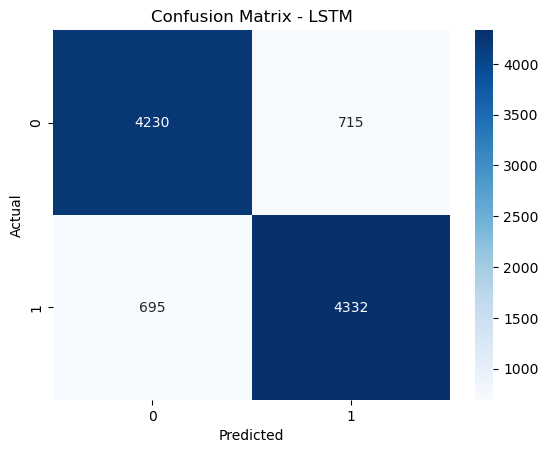

In [26]:
plt.figure()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LSTM")

plt.show()

<Axes: >

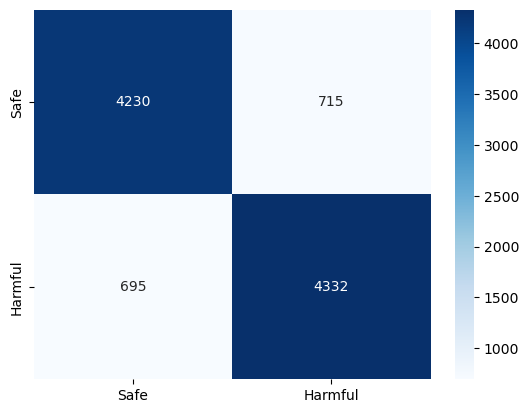

In [25]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Safe", "Harmful"],
    yticklabels=["Safe", "Harmful"]
)

# LSTM Model Analysis

The LSTM model achieved performance comparable to transformer-based models (MiniLM embeddings) by learning sequential patterns and word dependencies in text.

However, it requires higher computational resources and longer training time compared to the MiniLM + SVM approach.

This highlights the trade-off between performance and efficiency, where LSTM provides strong sequence learning capabilities, while transformer-based embeddings combined with traditional classifiers offer a more efficient and practical solution for deployment.

# Final Comparative Analysis of Models

| Feature Type | Model | Accuracy |
|-------------|------|---------|
| Transformer (MiniLM) | SVM | **85.02%** |
| Transformer (MiniLM) | Logistic Regression | 84.15% |
| Transformer (MiniLM) | Random Forest | 81.60% |
| TF-IDF | SVM | 84.57% |
| TF-IDF | Logistic Regression | 84.25% |
| TF-IDF | Random Forest | 79.95% |
| LSTM | Deep Learning Model | **86.00%** |

---

### Comparative Analysis

The comparison between TF-IDF, transformer-based embeddings (MiniLM), and LSTM models shows that all approaches perform well for cyberbullying detection.

Transformer-based models slightly outperform TF-IDF due to their ability to capture contextual meaning in text. TF-IDF also achieved competitive performance, indicating that traditional feature extraction methods can still be effective when combined with strong classifiers such as SVM.

The LSTM model achieved the highest accuracy among all models by learning sequential patterns and word dependencies in the text. However, it requires higher computational resources and longer training time compared to the MiniLM + SVM approach.

Among all models, Support Vector Machine (SVM) consistently performed the best across both TF-IDF and transformer-based features. Despite LSTM achieving slightly higher accuracy, the transformer-based MiniLM + SVM model was selected as the final model due to its balance between performance, efficiency, and ease of deployment.

# Challenges Faced

Several challenges were encountered during the development of this project:

- **Dataset Imbalance:** The original dataset had an unequal distribution of classes, which required downsampling to ensure balanced learning.

- **Data Integration:** Combining multiple datasets with different formats and label structures required preprocessing and standardization.

- **Text Noise:** Social media data contains slang, abbreviations, and irregular formatting, making preprocessing essential.

- **Model Selection:** Choosing the most suitable model required comparing multiple approaches, including TF-IDF, transformer-based embeddings, and LSTM.

- **Computational Constraints:** Training deep learning models such as LSTM required more time and computational resources compared to traditional models.

- **Kernel/Environment Issues:** During experimentation, issues such as kernel crashes and memory limitations were encountered, especially when handling large datasets and embeddings.

- **Contextual Limitations:** The model may struggle to detect subtle or implicit harmful content, such as manipulation or sarcasm, due to limited contextual understanding.

# Importance of the Project

This project addresses a critical real-world problem of detecting harmful content in online communication.

- **Protecting Users:** Helps identify harmful or abusive messages that may negatively impact mental health, especially among younger users.

- **Automation:** Reduces the need for manual monitoring by automatically detecting harmful content.

- **Real-time Detection:** Enables quick identification of harmful messages through a deployed web application.

- **Practical Application:** Demonstrates how NLP and machine learning can be applied to solve real-world problems.

- **Scalability:** The system can be extended to integrate with social media platforms for continuous monitoring.

- **Awareness:** Highlights the importance of responsible digital communication and online safety.

# Future Work

The current system can be further improved in several ways:

- **Fine-tuning Transformer Models:** Instead of using fixed embeddings, fine-tuning transformer models could improve performance.

- **Multi-class Classification:** Extending the system to detect specific categories such as racism, sexism, and harassment.

- **Context-aware Detection:** Incorporating conversation-level context to detect subtle harmful behavior.

- **Larger Dataset Usage:** Training on larger and more diverse datasets to improve generalization.

- **Real-time Integration:** Integrating the system with social media platforms or messaging systems.

- **Improved Alert System:** Implementing real email or notification systems instead of simulated alerts.

- **Explainability:** Adding model interpretability features to understand why a message is classified as harmful.

# Conclusion

In this project, an AI-based system was developed to detect harmful online content using Natural Language Processing techniques. The goal was to classify text as either Safe or Harmful and provide a practical solution for identifying potentially abusive or toxic interactions.

Multiple approaches were implemented and compared, including TF-IDF with traditional machine learning models, transformer-based embeddings using MiniLM combined with machine learning classifiers, and an LSTM-based deep learning model. Each approach was evaluated using metrics such as accuracy, precision, recall, F1-score, and confusion matrix.

The results showed that while the LSTM model achieved slightly higher accuracy, transformer-based embeddings combined with Support Vector Machine (SVM) provided a strong balance between performance, computational efficiency, and ease of deployment. Therefore, the MiniLM + SVM model was selected as the final model for this project.

The system was successfully deployed as a Streamlit application, allowing real-time text input, prediction, alert generation, and case logging with timestamps. This demonstrates the practical applicability of machine learning in addressing real-world problems such as cyberbullying detection.

Overall, the project highlights how different NLP techniques can be compared and applied to build an effective and efficient system for improving online safety.

# PART 2. Streamlit Application Overview

A web-based application is developed using Streamlit to provide a user-friendly interface for detecting harmful online content in real time.

The application integrates the trained transformer-based model (MiniLM embeddings with SVM) and allows users to input text for analysis. The system processes the input, generates embeddings, and classifies the text as either Safe or Harmful.

### Key Features

- **Real-time Text Analysis:** Users can enter any text and receive instant predictions.  
- **Binary Classification:** Messages are classified as Safe or Harmful.  
- **Automatic Alert System:** Harmful content triggers an alert message indicating potential risk.  
- **Simulated Notification:** A mock email alert is generated to represent parental notification.  
- **Case Logging:** All analyzed inputs are stored in a local file (`history.csv`) along with timestamps.  
- **History Tracking:** Users can view previously analyzed messages and their results.

### Workflow

User Input → Text Cleaning → Transformer Embedding (MiniLM) → SVM Prediction → Result Display → Alert & Logging

This application demonstrates the practical deployment of the trained model and highlights how machine learning can be used to build real-time systems for improving online safety.

## Limitations

While the system performs well in detecting harmful content, there are several limitations:

- **Dataset Bias Toward Toxicity:** The model is primarily trained on datasets focused on toxic, abusive, and offensive language. As a result, it performs better on detecting general toxicity compared to more specific categories such as sexual content or grooming-related conversations.

- **Limited Detection of Sexual or Grooming Content:** The system may not reliably detect subtle or implicit sexual content, especially in cases where the language is indirect or context-dependent.

- **Lack of Context Awareness:** The model analyzes individual messages rather than full conversations, which limits its ability to detect manipulative or long-term harmful behavior.

- **Difficulty with Subtle Language:** Sarcasm, coded language, and indirect harmful expressions may not always be correctly classified.

- **Binary Classification Constraint:** The system only classifies messages as Safe or Harmful, without identifying specific types of harm such as racism, sexism, or harassment.

- **Dependence on Training Data:** The performance of the model is directly influenced by the quality and diversity of the training data.

These limitations highlight the need for more diverse datasets and advanced models to improve detection of complex and context-based harmful behavior.